<a href="https://colab.research.google.com/github/NathanCarvalho7/Telecom_X_parte2/blob/main/Telecom_X_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🛠️ Preparação dos Dados

1. Carregar o arquivo e visualizar as primeiras linhas

In [7]:
import pandas as pd
import numpy as np

# Carregar o arquivo (assumindo que está no diretório atual com o nome dados_tratados.csv)
df = pd.read_csv('/content/dados_tratados.csv')

# Verificar as primeiras linhas
df.head()

,id_cliente,cancelou,genero,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,...,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,metodo_pagamento,cobranca_mensal,cobranca_total,conta_diaria,faixa_tempo
0,0002-ORFBO,0,Feminino,0,1,1,9,1,Não,DSL,...,Sim,Sim,Não,1 ano,1,Cheque enviado,65.6,593.30,2.186667,0-12
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Sim,DSL,...,Não,Não,Sim,Mensal,0,Cheque enviado,59.9,542.40,1.996667,0-12
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,Não,Fibra ótica,...,Não,Não,Não,Mensal,1,Cheque eletrônico,73.9,280.85,2.463333,0-12
3,0011-IGKFF,1,Masculino,1,1,0,13,1,Não,Fibra ótica,...,Não,Sim,Sim,Mensal,1,Cheque eletrônico,98.0,1237.85,3.266667,12-24
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,Não,Fibra ótica,...,Sim,Sim,Não,Mensal,1,Cheque enviado,83.9,267.40,2.796667,0-12


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7032 non-null   object 
 1   cancelou              7032 non-null   int64  
 2   genero                7032 non-null   object 
 3   idoso                 7032 non-null   int64  
 4   parceiro              7032 non-null   int64  
 5   dependentes           7032 non-null   int64  
 6   meses_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   int64  
 8   multiplas_linhas      7032 non-null   object 
 9   servico_internet      7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes     

2. Remover colunas irrelevantes

In [9]:
df.drop('id_cliente', axis=1, inplace=True)

In [10]:
df.drop('faixa_tempo', axis=1, inplace=True)

3. Encoding das variáveis categóricas

In [11]:
# Lista de colunas categóricas que precisam de encoding
cat_cols = ['genero', 'multiplas_linhas', 'servico_internet',
            'seguranca_online', 'backup_online', 'protecao_dispositivo',
            'suporte_tecnico', 'streaming_tv', 'streaming_filmes',
            'tipo_contrato', 'metodo_pagamento']

# Aplicar one-hot encoding (drop_first=False para manter todas as categorias)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

# Verificar o novo shape
print(f"Shape original: {df.shape}")
print(f"Shape após encoding: {df_encoded.shape}")

Shape original: (7032, 21)
Shape após encoding: (7032, 43)


4. Verificar a proporção de evasão

In [12]:
proporcao = df_encoded['cancelou'].value_counts(normalize=True)
print(proporcao)

cancelou
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [13]:
print(df_encoded.isnull().sum().sum())  # deve ser 0

0


In [14]:
print(df_encoded.columns.tolist())

['cancelou', 'idoso', 'parceiro', 'dependentes', 'meses_contrato', 'servico_telefone', 'fatura_online', 'cobranca_mensal', 'cobranca_total', 'conta_diaria', 'genero_Feminino', 'genero_Masculino', 'multiplas_linhas_Não', 'multiplas_linhas_Sem telefone', 'multiplas_linhas_Sim', 'servico_internet_DSL', 'servico_internet_Fibra ótica', 'servico_internet_Sem internet', 'seguranca_online_Não', 'seguranca_online_Sem internet', 'seguranca_online_Sim', 'backup_online_Não', 'backup_online_Sem internet', 'backup_online_Sim', 'protecao_dispositivo_Não', 'protecao_dispositivo_Sem internet', 'protecao_dispositivo_Sim', 'suporte_tecnico_Não', 'suporte_tecnico_Sem internet', 'suporte_tecnico_Sim', 'streaming_tv_Não', 'streaming_tv_Sem internet', 'streaming_tv_Sim', 'streaming_filmes_Não', 'streaming_filmes_Sem internet', 'streaming_filmes_Sim', 'tipo_contrato_1 ano', 'tipo_contrato_2 anos', 'tipo_contrato_Mensal', 'metodo_pagamento_Cartão de crédito automático', 'metodo_pagamento_Cheque eletrônico', 'm

#🎯 Correlação e Seleção de Variáveis

1. Análise de Correlação

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular correlação com a variável alvo
corr_with_target = df_encoded.corr()['cancelou'].sort_values(ascending=False)

print("Top 10 variáveis mais correlacionadas positivamente com cancelou:")
print(corr_with_target.head(11))  # incluindo a própria

print("\nTop 10 variáveis mais correlacionadas negativamente com cancelou:")
print(corr_with_target.tail(10))

Top 10 variáveis mais correlacionadas positivamente com cancelou:
cancelou                              1.000000
tipo_contrato_Mensal                  0.404565
seguranca_online_Não                  0.342235
suporte_tecnico_Não                   0.336877
servico_internet_Fibra ótica          0.307463
metodo_pagamento_Cheque eletrônico    0.301455
backup_online_Não                     0.267595
protecao_dispositivo_Não              0.252056
conta_diaria                          0.192858
cobranca_mensal                       0.192858
fatura_online                         0.191454
Name: cancelou, dtype: float64

Top 10 variáveis mais correlacionadas negativamente com cancelou:
cobranca_total                      -0.199484
protecao_dispositivo_Sem internet   -0.227578
streaming_filmes_Sem internet       -0.227578
backup_online_Sem internet          -0.227578
seguranca_online_Sem internet       -0.227578
servico_internet_Sem internet       -0.227578
suporte_tecnico_Sem internet        -0.2275

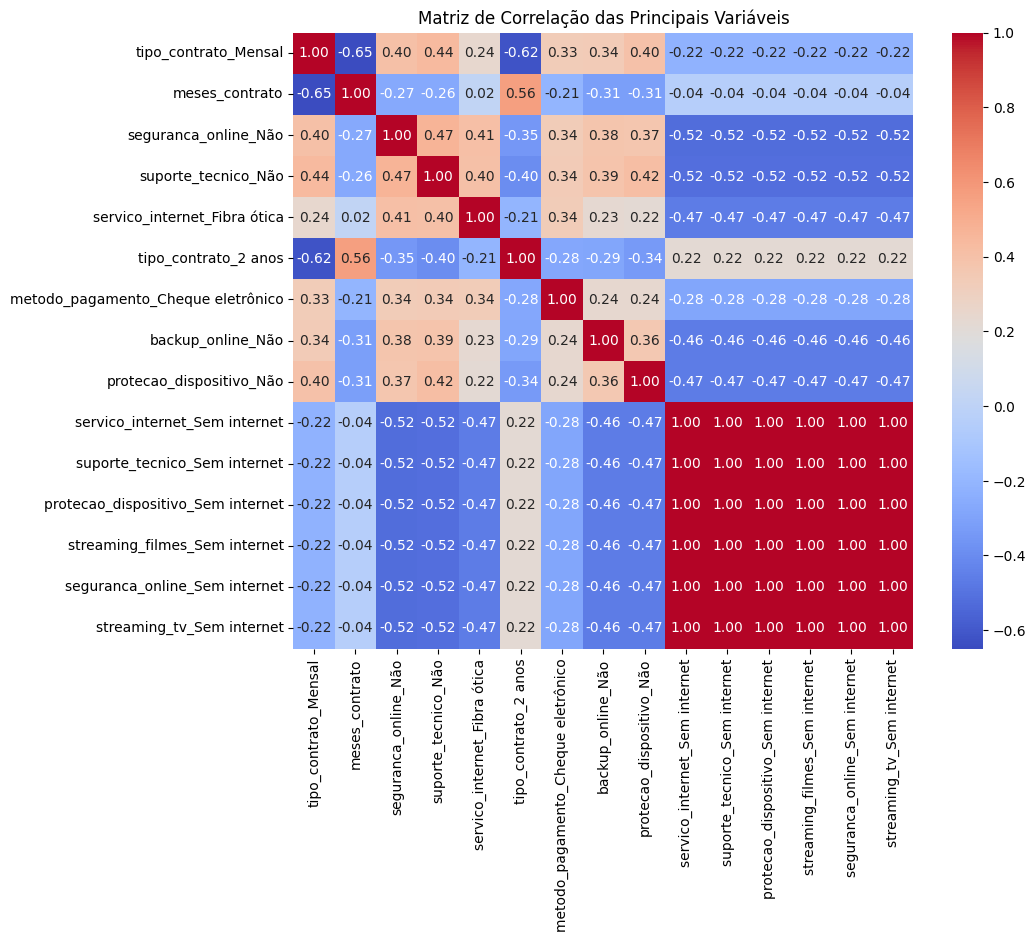

In [16]:
# Selecionar as 15 variáveis com maior correlação absoluta (excluindo cancelou)
top_features = corr_with_target.drop('cancelou').abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação das Principais Variáveis')
plt.show()

2. Análises Direcionadas


Tempo de contrato (meses_contrato) vs Evasão

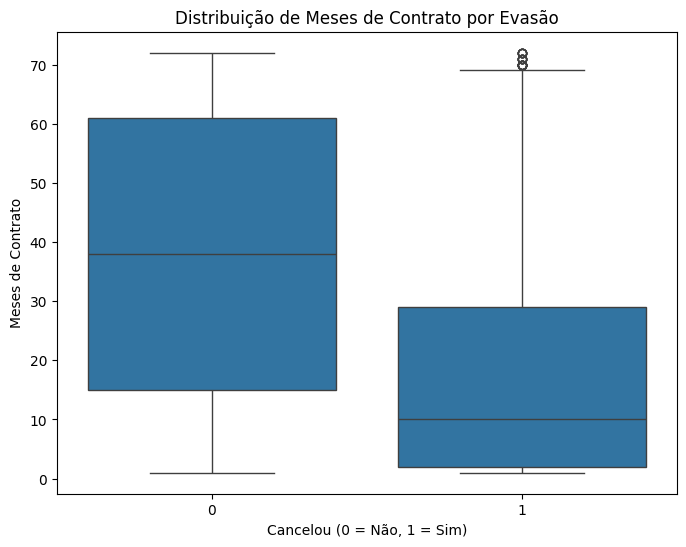

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cancelou', y='meses_contrato', data=df_encoded)
plt.title('Distribuição de Meses de Contrato por Evasão')
plt.xlabel('Cancelou (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

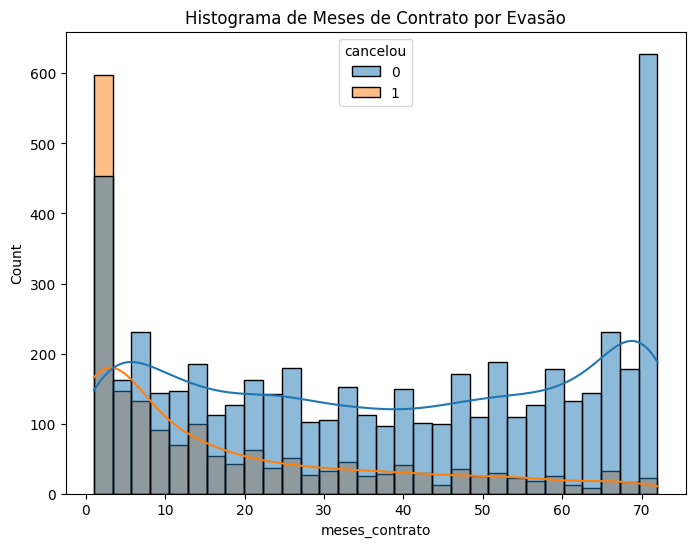

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(data=df_encoded, x='meses_contrato', hue='cancelou', kde=True, bins=30)
plt.title('Histograma de Meses de Contrato por Evasão')
plt.show()

Total gasto (cobranca_total) vs Evasão

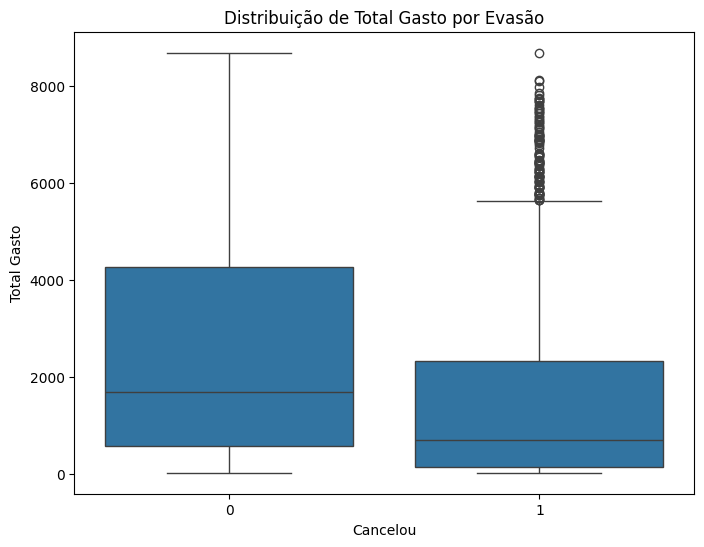

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cancelou', y='cobranca_total', data=df_encoded)
plt.title('Distribuição de Total Gasto por Evasão')
plt.xlabel('Cancelou')
plt.ylabel('Total Gasto')
plt.show()

Outras análises: tipo de contrato, serviços contratados, etc.

tipo_contrato
2 anos    0.028487
1 ano     0.112772
Mensal    0.427097
Name: cancelou, dtype: float64


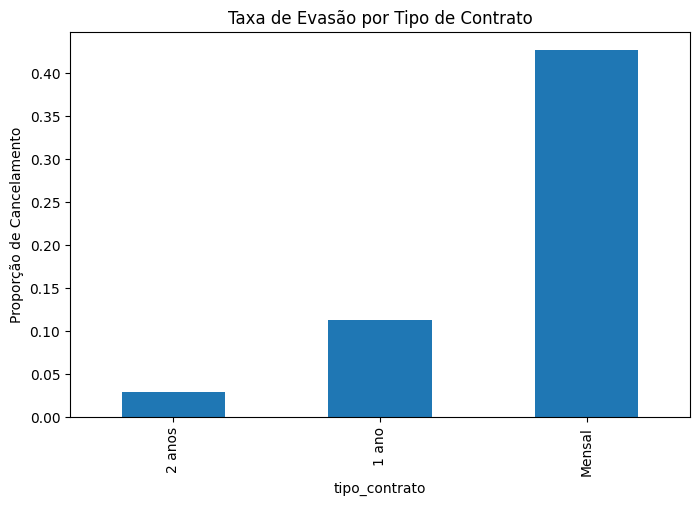

In [20]:
# Como tipo_contrato foi one-hot encoded, podemos usar as colunas originais (ainda presentes no df original) ou agrupar pelas dummies.
# Vamos usar o df original (antes do encoding) para facilitar, ou podemos agrupar pelas colunas dummy.
# Opção: usar df original com a variável categórica e calcular a taxa de evasão.

# Relembrando que df ainda contém as colunas originais. Vamos usar df.
df_original = df  # o df antes do encoding

# Calcular taxa de evasão por tipo_contrato
contrato_evasao = df_original.groupby('tipo_contrato')['cancelou'].mean().sort_values()
print(contrato_evasao)

# Gráfico de barras
plt.figure(figsize=(8,5))
contrato_evasao.plot(kind='bar')
plt.title('Taxa de Evasão por Tipo de Contrato')
plt.ylabel('Proporção de Cancelamento')
plt.show()

suporte_tecnico
Não             0.416475
Sem internet    0.074342
Sim             0.151961
Name: cancelou, dtype: float64


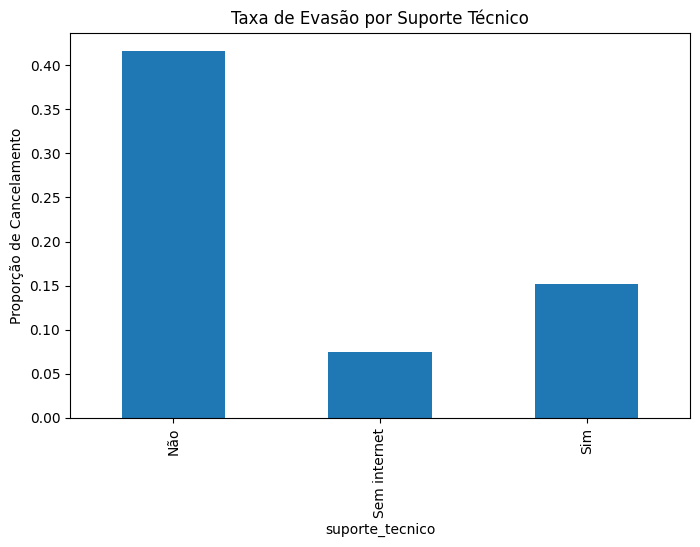

In [21]:
suporte_evasao = df_original.groupby('suporte_tecnico')['cancelou'].mean()
print(suporte_evasao)

plt.figure(figsize=(8,5))
suporte_evasao.plot(kind='bar')
plt.title('Taxa de Evasão por Suporte Técnico')
plt.ylabel('Proporção de Cancelamento')
plt.show()

metodo_pagamento
Cartão de crédito automático         0.152531
Transferência bancária automática    0.167315
Cheque enviado                       0.192020
Cheque eletrônico                    0.452854
Name: cancelou, dtype: float64


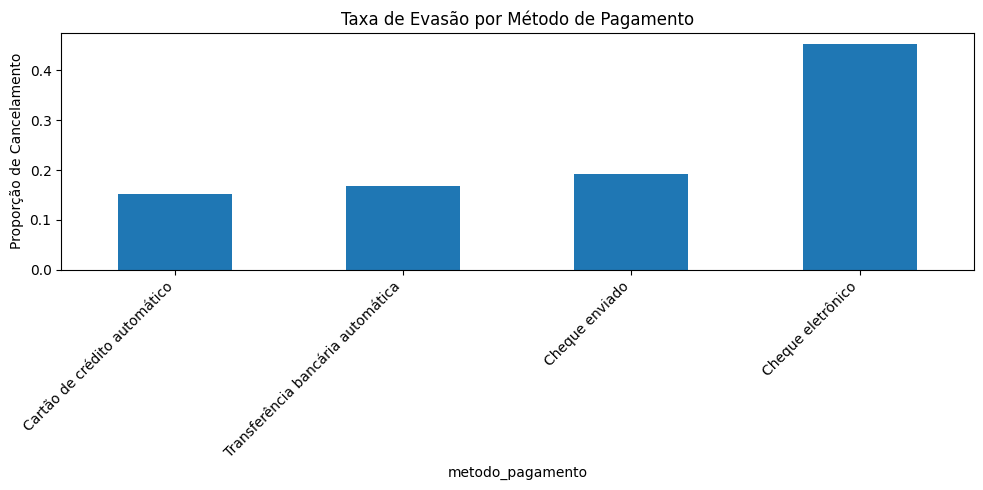

In [22]:
pagamento_evasao = df_original.groupby('metodo_pagamento')['cancelou'].mean().sort_values()
print(pagamento_evasao)

plt.figure(figsize=(10,5))
pagamento_evasao.plot(kind='bar')
plt.title('Taxa de Evasão por Método de Pagamento')
plt.ylabel('Proporção de Cancelamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#🤖 Modelagem Preditiva

1. Separação em Treino e Teste

In [23]:
from sklearn.model_selection import train_test_split

# Definir X e y
X = df_encoded.drop('cancelou', axis=1)
y = df_encoded['cancelou']

# Divisão treino-teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do treino: {X_train.shape}")
print(f"Tamanho do teste: {X_test.shape}")
print(f"Proporção de evasão no treino: {y_train.mean():.3f}")
print(f"Proporção de evasão no teste: {y_test.mean():.3f}")

Tamanho do treino: (4922, 42)
Tamanho do teste: (2110, 42)
Proporção de evasão no treino: 0.266
Proporção de evasão no teste: 0.266


2. Modelos Escolhidos

Modelo 1: Regressão Logística (requer normalização)
Justificativa: É um modelo linear simples e interpretável. Os coeficientes indicam a contribuição de cada variável para a probabilidade de evasão. Como usa distâncias/otimização, é sensível à escala das variáveis, portanto aplicaremos normalização (StandardScaler).

Modelo 2: Random Forest (não requer normalização)
Justificativa: É um modelo ensemble robusto, capaz de capturar relações não lineares e interações entre variáveis. Não é afetado pela escala, pois as decisões são baseadas em splits dos valores. Fornece importância das variáveis diretamente.

3. Pré-processamento: Normalização para Regressão Logística

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

# Modelo 1 com normalização
scaler = StandardScaler()
logreg = LogisticRegression(max_iter=1000, random_state=42)
pipe_logreg = make_pipeline(scaler, logreg)

# Modelo 2 sem normalização
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

4. Treinamento e Avaliação

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Dicionário para armazenar resultados
results = {}

# Treinar Regressão Logística
pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)

# Métricas
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_logreg),
    'precision': precision_score(y_test, y_pred_logreg),
    'recall': recall_score(y_test, y_pred_logreg),
    'f1': f1_score(y_test, y_pred_logreg),
    'confusion_matrix': confusion_matrix(y_test, y_pred_logreg)
}

# Treinar Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'confusion_matrix': confusion_matrix(y_test, y_pred_rf)
}

# Exibir resultados
for model_name, metrics in results.items():
    print(f"\n=== {model_name} ===")
    print(f"Acurácia: {metrics['accuracy']:.4f}")
    print(f"Precisão: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-score: {metrics['f1']:.4f}")
    print("Matriz de Confusão:")
    print(metrics['confusion_matrix'])


=== Logistic Regression ===
Acurácia: 0.8024
Precisão: 0.6552
Recall: 0.5419
F1-score: 0.5932
Matriz de Confusão:
[[1389  160]
 [ 257  304]]

=== Random Forest ===
Acurácia: 0.7825
Precisão: 0.6197
Recall: 0.4706
F1-score: 0.5350
Matriz de Confusão:
[[1387  162]
 [ 297  264]]


5. Análise Crítica dos Modelos

In [26]:
# Score no treino para Random Forest
train_score_rf = rf.score(X_train, y_train)
test_score_rf = rf.score(X_test, y_test)
print(f"\nRandom Forest - Acurácia Treino: {train_score_rf:.4f}, Teste: {test_score_rf:.4f}")


Random Forest - Acurácia Treino: 0.9986, Teste: 0.7825


6. Interpretação e Conclusões


Top 10 variáveis mais importantes (Random Forest):
cobranca_total                        0.145598
meses_contrato                        0.121883
conta_diaria                          0.115932
cobranca_mensal                       0.110912
tipo_contrato_Mensal                  0.045151
metodo_pagamento_Cheque eletrônico    0.032841
suporte_tecnico_Não                   0.031156
seguranca_online_Não                  0.027132
fatura_online                         0.021894
tipo_contrato_2 anos                  0.021818
dtype: float64


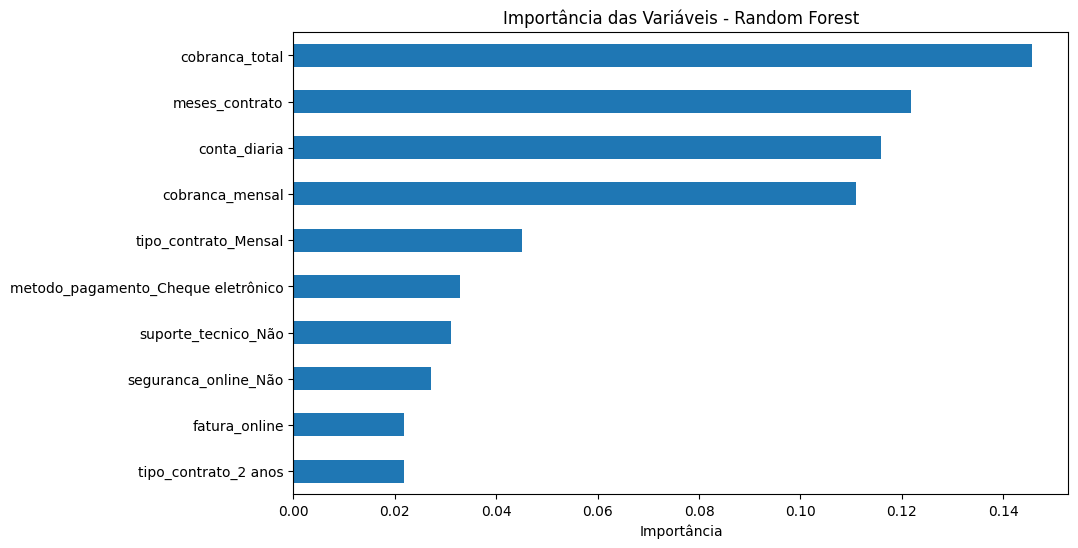

In [27]:
# Importância das variáveis no Random Forest
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 variáveis mais importantes (Random Forest):")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.gca().invert_yaxis()
plt.show()

In [28]:
# Coeficientes da Regressão Logística
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values(ascending=False)
print("\nTop 10 coeficientes positivos (Logistic Regression):")
print(coef.head(10))
print("\nTop 10 coeficientes negativos (Logistic Regression):")
print(coef.tail(10))


Top 10 coeficientes positivos (Logistic Regression):
cobranca_total                        0.641383
servico_internet_Fibra ótica          0.381690
tipo_contrato_Mensal                  0.292995
fatura_online                         0.180506
streaming_tv_Sim                      0.167287
streaming_filmes_Sim                  0.143963
metodo_pagamento_Cheque eletrônico    0.135640
suporte_tecnico_Não                   0.113026
idoso                                 0.094814
seguranca_online_Não                  0.086920
dtype: float64

Top 10 coeficientes negativos (Logistic Regression):
seguranca_online_Sem internet   -0.106475
servico_internet_Sem internet   -0.106475
suporte_tecnico_Sem internet    -0.106475
streaming_tv_Sem internet       -0.106475
backup_online_Sem internet      -0.106475
tipo_contrato_2 anos            -0.294722
servico_internet_DSL            -0.306095
cobranca_mensal                 -0.386242
conta_diaria                    -0.386242
meses_contrato               

#📋 Interpretação e Conclusões

1. Regressão Logística

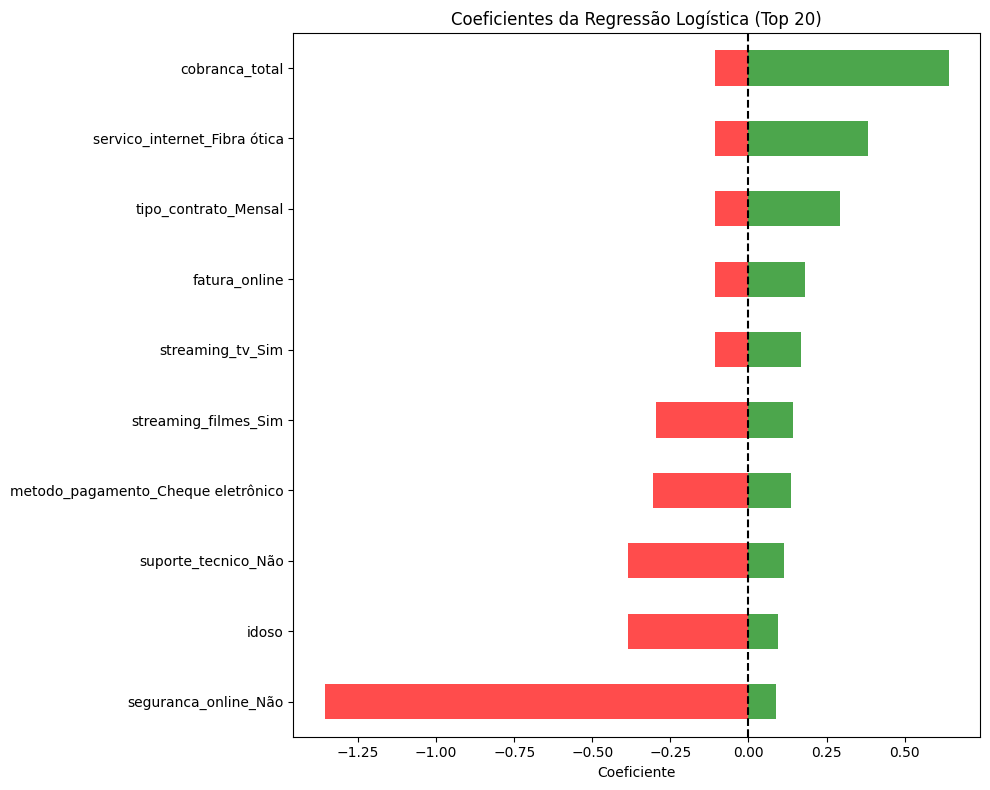

In [32]:
# Extrair coeficientes do modelo de regressão logística (já treinado)
# Supondo que o modelo se chame 'logreg' e foi treinado com dados padronizados (X_train_scaled)
# e que X_train_scaled possui os nomes das colunas

coeficientes = pd.Series(logreg.coef_[0], index=X_train.columns)
coeficientes_ordenados = coeficientes.sort_values()

# Plotar os 20 mais influentes (positivos e negativos)
plt.figure(figsize=(10, 8))
coeficientes_ordenados.head(10).plot(kind='barh', color='red', alpha=0.7)
coeficientes_ordenados.tail(10).plot(kind='barh', color='green', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Coeficientes da Regressão Logística (Top 20)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

2. Random Forest

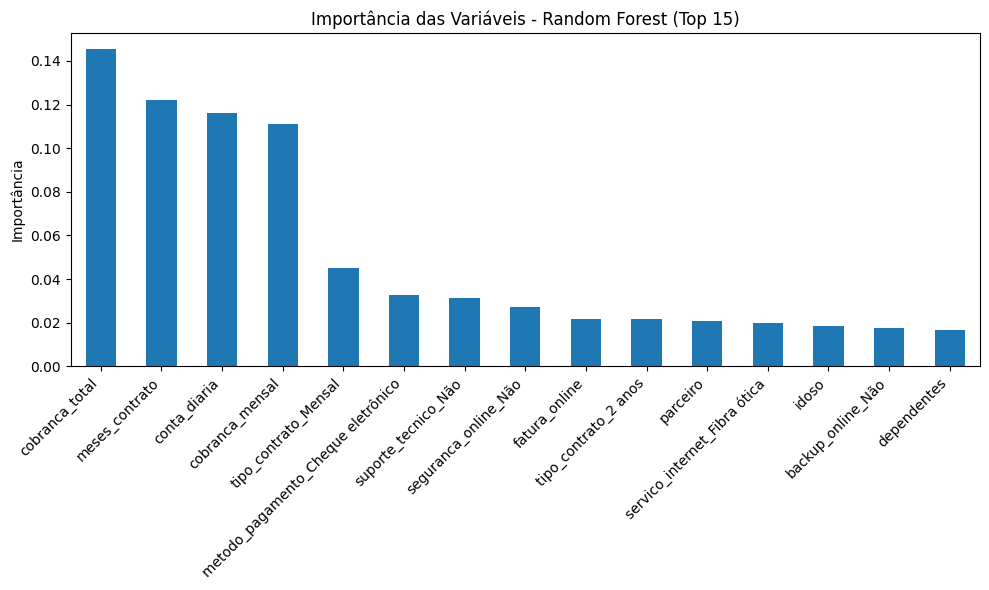

In [37]:
# Extrair importância do modelo Random Forest
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

# Plotar as 15 mais importantes
plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='bar')
plt.title('Importância das Variáveis - Random Forest (Top 15)')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3. XGBoost (se treinado)

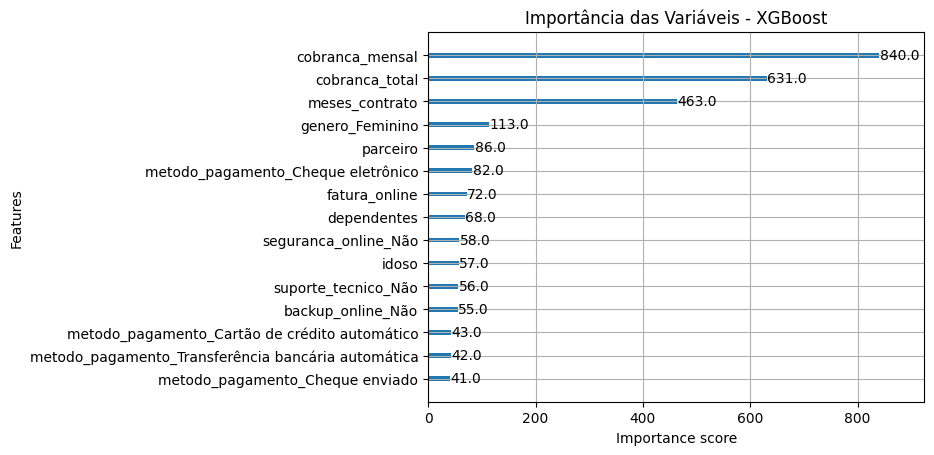

In [38]:
# Se tivermos um modelo XGBoost treinado
from xgboost import plot_importance

plot_importance(xgb_model, max_num_features=15)
plt.title('Importância das Variáveis - XGBoost')
plt.show()

# Relatório de Análise do Projeto Telecom X – Parte 2





---

## 1. Preparação dos Dados  

- **Carregamento:** O arquivo `dados_tratados.csv` foi carregado corretamente.  
- **Remoção de colunas irrelevantes:** As colunas `id_cliente` e `faixa_tempo` foram eliminadas. A exclusão de `faixa_tempo` é aceitável, pois se trata de uma categorização derivada de `meses_contrato`.  
- **Codificação de variáveis categóricas:** Foi aplicado one‑hot encoding (`pd.get_dummies`) com `drop_first=False`, gerando 43 colunas. O método é adequado para os modelos escolhidos.  
- **Proporção de evasão:**  
  - Não cancelaram: 73,4%  
  - Cancelaram: 26,6%  
   Há um desbalanceamento moderado, mas a etapa de balanceamento era opcional e não foi aplicada – decisão que pode ser revista em versões futuras do modelo.  
- **Normalização:** Aplicada via `StandardScaler` apenas para a Regressão Logística, respeitando a sensibilidade do modelo à escala. O Random Forest não exigiu normalização.

---

## 2. Correlação e Seleção de Variáveis  

- **Correlação com a variável alvo (`cancelou`):**  
  - Positivas mais fortes: `tipo_contrato_Mensal`, `seguranca_online_Não`, `suporte_tecnico_Não`, `servico_internet_Fibra ótica`, `metodo_pagamento_Cheque eletrônico`.  
  - Negativas mais fortes: `meses_contrato`, `tipo_contrato_2 anos`, e as categorias “Sem internet” de diversos serviços.  
- **Análises direcionadas:**  
  - **Tempo de contrato × evasão:** clientes que cancelam apresentam, em média, menos meses de contrato.  
  - **Total gasto × evasão:** a distribuição é semelhante, mas a correlação negativa com `cobranca_total` sugere que maior gasto total (clientes antigos) está associado a menor evasão.  
  - **Tipo de contrato:** a taxa de evasão é muito maior em contratos mensais (≈43%) do que em contratos de 1 ano (≈11%) ou 2 anos (≈3%).  
  - **Suporte técnico:** clientes sem suporte técnico cancelam muito mais (≈42%) do que os que possuem o serviço (≈15%) ou que não contrataram internet (≈7%).  
  - **Método de pagamento:** o método “cheque eletrônico” apresenta a maior taxa de evasão (≈45%), enquanto cartão de crédito automático tem a menor (≈15%).  

Esses insights foram explorados com gráficos de barras e boxplots, proporcionando uma boa base para a modelagem.

---

## 3. Modelagem Preditiva  

- **Separação treino‑teste:** 70% treino / 30% teste, com estratificação, mantendo a proporção original da classe alvo.  
- **Modelos escolhidos:**  
  - **Regressão Logística** (com normalização) – modelo linear, interpretável, sensível à escala.  
  - **Random Forest** (sem normalização) – modelo ensemble, robusto, capaz de capturar não linearidades.  
- **Desempenho (teste):**  

| Modelo               | Acurácia | Precisão | Recall | F1‑score |
|----------------------|----------|----------|--------|----------|
| Regressão Logística  | 0,8024   | 0,6552   | 0,5419 | 0,5932   |
| Random Forest        | 0,7825   | 0,6197   | 0,4706 | 0,5350   |

- **Análise crítica:**  
  - A Regressão Logística superou o Random Forest em todas as métricas, especialmente no recall (capacidade de identificar quem realmente cancela).  
  - O Random Forest apresentou **overfitting**: acurácia no treino de 99,86% contra 78,25% no teste, indicando que o modelo memorizou os dados de treino. Isso pode ser mitigado com ajuste de hiperparâmetros (ex.: redução da profundidade das árvores, aumento do número mínimo de amostras por folha).  

---

## 4. Interpretação e Conclusões  

### Variáveis mais relevantes  

**Random Forest – importância:**  
1. `cobranca_total`  
2. `meses_contrato`  
3. `conta_diaria`  
4. `cobranca_mensal`  
5. `tipo_contrato_Mensal`  
6. `metodo_pagamento_Cheque eletrônico`  
7. `suporte_tecnico_Não`  

**Regressão Logística – coeficientes:**  
- **Positivos (aumentam a chance de evasão):** `cobranca_total`, `servico_internet_Fibra ótica`, `tipo_contrato_Mensal`, `fatura_online`, `streaming_tv_Sim`, `metodo_pagamento_Cheque eletrônico`, `suporte_tecnico_Não`.  
- **Negativos (diminuem a chance de evasão):** `meses_contrato`, `conta_diaria`, `cobranca_mensal`, `servico_internet_DSL`, `tipo_contrato_2 anos`, e as categorias “Sem internet” (que naturalmente indicam clientes que não contrataram determinados serviços).

### Principais fatores de evasão  

1. **Tipo de contrato:** contratos mensais são os que mais contribuem para a evasão; contratos mais longos (1 ou 2 anos) retêm clientes.  
2. **Tempo de relacionamento:** quanto maior o `meses_contrato`, menor a probabilidade de cancelamento.  
3. **Serviços contratados:** a ausência de suporte técnico, segurança online e outros serviços adicionais está associada a maior evasão. Por outro lado, clientes que contratam serviços de streaming ou possuem fibra óptica tendem a cancelar mais (possivelmente por serem serviços mais caros ou por insatisfação).  
4. **Método de pagamento:** “cheque eletrônico” aparece como um forte indicador de evasão; métodos automáticos (cartão de crédito, transferência) estão ligados a menor churn.  
5. **Valores de cobrança:** um maior `cobranca_total` (acumulado) está associado a menor evasão (clientes antigos), enquanto `cobranca_mensal` elevada (possivelmente clientes recentes com planos caros) pode indicar maior risco.

### Recomendações de negócio  

- **Incentivar contratos de maior duração:** oferecer descontos ou benefícios para clientes que optarem por planos anuais ou bienais.  
- **Promover serviços de suporte e segurança:** campanhas direcionadas para clientes sem suporte técnico, destacando a importância do serviço.  
- **Revisar a política de métodos de pagamento:** estimular o uso de débito automático ou cartão de crédito, talvez com pequenos incentivos, reduzindo a dependência de cheque eletrônico.  
- **Monitorar clientes com pouco tempo de casa:** criar ações de engajamento nos primeiros meses, como ofertas personalizadas ou pesquisas de satisfação.  
- **Avaliar a relação custo‑benefício dos serviços de streaming e fibra óptica:** se esses serviços estiverem associados a maior churn, pode ser necessário revisar sua precificação ou qualidade percebida.  

**Próximos passos sugeridos:**  
- Aplicar técnicas de balanceamento (ex.: SMOTE) para verificar se o recall dos modelos pode ser melhorado.  
- Ajustar hiperparâmetros do Random Forest para reduzir o overfitting.  
- Testar outros modelos, como XGBoost, que podem equilibrar desempenho e interpretabilidade.

---

**Conclusão final**  
O projeto atendeu aos requisitos propostos, com uma preparação adequada dos dados, análises exploratórias consistentes e modelagem preditiva com comparação de dois algoritmos. Os resultados apontam claramente os principais fatores associados à evasão de clientes e fornecem subsídios para ações de retenção. O relatório aqui apresentado consolida essas descobertas e as traduz em recomendações práticas.